## 
Comparison of the Confidence Intervals computed by the simulate function provided by evgam (simulate) for the evgam GEV analyse and computed by pbooter a distillery bootstrap function for the extRemes GEV analyse (pbooter).

Both methods are using a 1000 iterations.
##
Evgam formula : list(AFI 

~ s(DJFtas,bs='cr',k=10)+s(cell,k= 50, bs=\"mrf\", xt = list(nb = nb)) +s(cell,k=12, bs=\"mrf\", xt = list(nb = nb),by=glost) ,

~ s(DJFtas,bs='cr',k=10)+s(cell,k=50, bs=\"mrf\", xt = list(nb = nb))+s(cell,k=12, bs=\"mrf\", xt = list(nb = nb),by=glost) , 

~ s(DJFtas,bs='cr',k=10)+s(cell,k=50, bs=\"mrf\", xt = list(nb = nb)))
##
extRemes time covariate : location.fun = ~glost, scale.fun = ~glost
##

In [28]:
import os

In [29]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
from copy import copy


In [30]:
from matplotlib import cm

In [31]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [32]:
import warnings
warnings.filterwarnings('ignore')


# READ FILES

In [ ]:
yearb=1941
yeare=2025
B=1000

ifile=f'/data//AFI/Colorado_evgam_scores_1941_2025.nc'

ds0 = xr.open_dataset(ifile)
rl1000 = ds0['rl100']
loc0 = ds0['location'] 
scale0 = ds0['scale'] 
shape0 = ds0['shape'] 
LocationDiff_q0 = ds0['LocationDiff_q']
ScaleDiff_q0 = ds0['ScaleDiff_q']
RLDiff_q0 = ds0['RLDiff_q']
RiskRatios_q0 = ds0['RiskRatios_q']
RLDiff_fitted0 = ds0['RLDiff_fitted']
CRPS0 = ds0['CRPS']
DawSeb0 = ds0['DawSeb']
SE0 = ds0['SE']
KS_D0 = ds0['KS_D']
KS_pvalue0 = ds0['KS_pvalue']
CVM_D0 = ds0['CVM_D']
CVM_pvalue0 = ds0['CVM_pvalue']

Tlon = ds0.lon.data
Tlat = ds0.lat.data


In [ ]:
yearb=1941
yeare=2025

ifile=f'/data//AFI/Colorado_ij_glost_extremes_EGfull_B{B}_1941_2025.nc'

ds1 = xr.open_dataset(ifile)
ds1 = ds1.assign_coords({'quantile':[0.05,0.5,0.95]})
rl1001 = ds1['rl100'] 
loc1 = ds1['location'] 
scale1 = ds1['scale'] 
shape1 = ds1['shape'] 
LocationDiff_q1 = ds1['LocationDiff_q']
ScaleDiff_q1 = ds1['ScaleDiff_q']
RLDiff_q1 = ds1['RLDiff_q']
RiskRatios_q1 = ds1['RiskRatios_q']
RLDiff_fitted1 = ds1['RLDiff_fitted']
CRPS1 = ds1['CRPS']
DawSeb1 = ds1['DawSeb']
SE1 = ds1['SE']
KS_D1 = ds1['KS_D']
KS_pvalue1 = ds1['KS_pvalue']
CVM_D1 = ds1['CVM_D']
CVM_pvalue1 = ds1['CVM_pvalue']



units = 'degree-days (°C-days)'

In [35]:
Tlabels = [f'Evgam, simulate, B={B}',f'extRemes, pbooter, B={B}']

Trl100 = [rl1000,rl1001]
Tloc = [loc0,loc1]
Tscale = [scale0,scale1]
Tshape = [shape0,shape1]
#
Tlocdiff = [LocationDiff_q0,LocationDiff_q1]
Tscadiff = [ScaleDiff_q0,ScaleDiff_q1]
TRL = [RLDiff_q0,RLDiff_q1]
TRR = [RiskRatios_q0,RiskRatios_q1]
TRLfitted = [rl1000.sel(time=yeare)-rl1000.sel(time=yearb),rl1001.sel(time=yeare)-rl1001.sel(time=yearb)]
#
TSE = [SE0,SE1]
TDawSeb = [DawSeb0,DawSeb1]
TCRPS = [CRPS0,CRPS1]
#
TKS_D = [KS_D0,KS_D1]
TKS_pvalue = [KS_pvalue0,KS_pvalue1]
TCVM_D = [CVM_D0,CVM_D1]
TCVM_pvalue = [CVM_pvalue0,CVM_pvalue1]


In [36]:
vq=[0.95,0.05]
proj=ccrs.PlateCarree()
Tquantile=['0.95','0.05','0.95-0.05']


Text(0.5, 0.98, 'Return Level 100year')

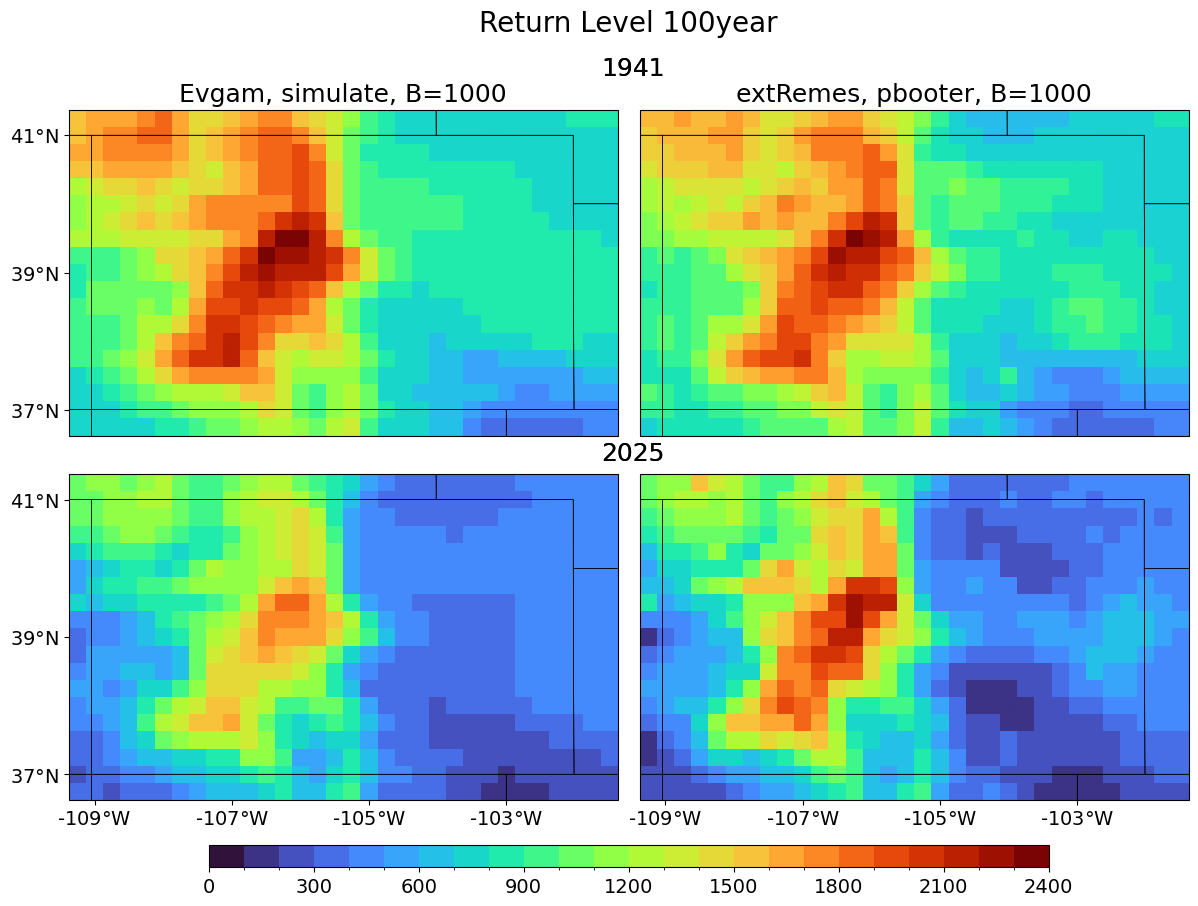

In [37]:
proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=2,ncols=2,figsize=(14,11),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.04)
ax = ax.flatten()
for ix in range(0,2):
  cc = Trl100[ix].sel(time=yearb).plot.pcolormesh(ax=ax[ix],cmap='turbo',levels=np.arange(0,2500,100),add_colorbar=False)
  cc = Trl100[ix].sel(time=yeare).plot.pcolormesh(ax=ax[ix+2],cmap='turbo',levels=np.arange(0,2500,100),add_colorbar=False)
  fig.text(0.48,0.92,yearb,fontsize=18)
  fig.text(0.48,0.57,yeare,fontsize=18)
  ####
for ix in range(0,len(ax)):  
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
 
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-2:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
    ax[ix].set_title('',fontsize=18)  
  elif ix <=1:
    ax[ix].set_title(f'{Tlabels[ix]}',fontsize=18)    
  else:
    ax[ix].set_title('',fontsize=18) 

for ix in range(0,3,2): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Return Level 100year',fontsize=20)  

Text(0.5, 0.98, 'Location parameter')

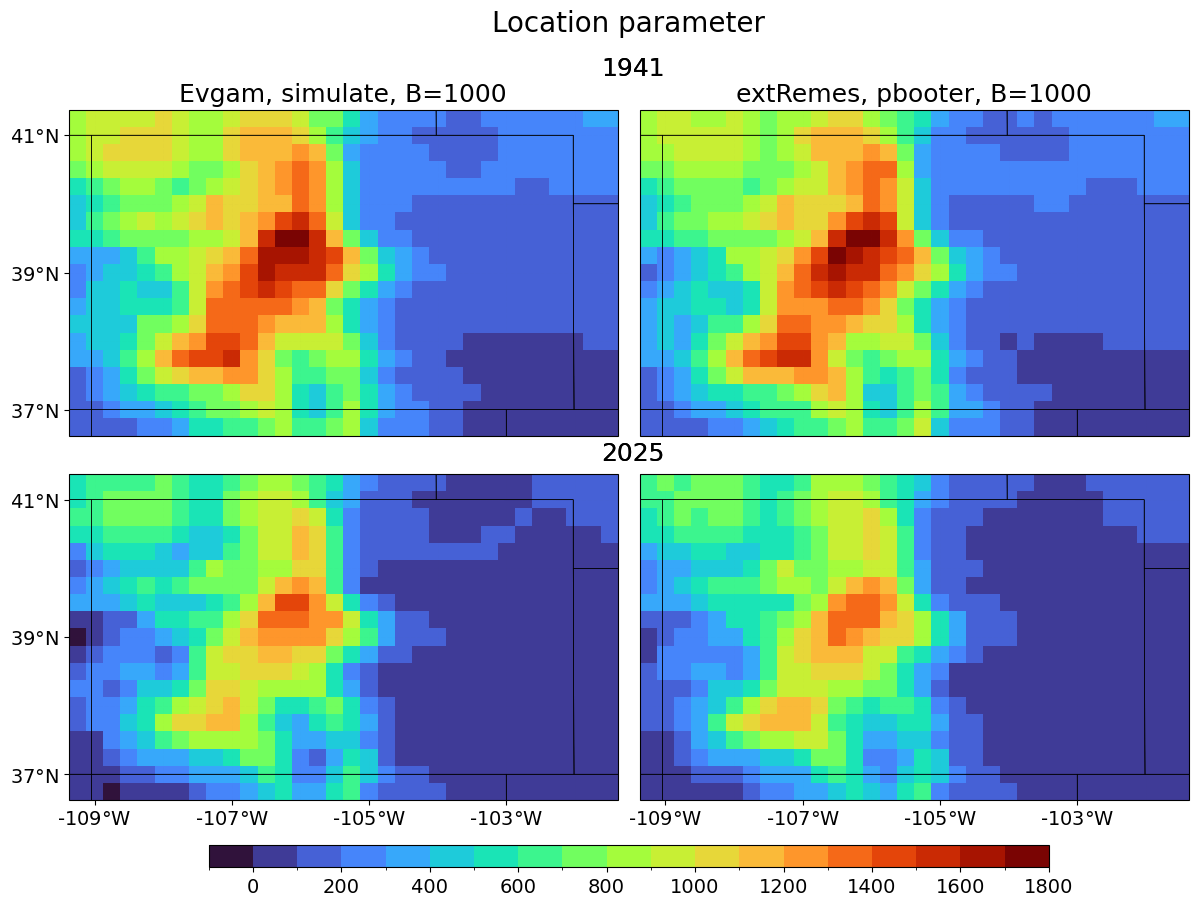

In [38]:
proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=2,ncols=2,figsize=(14,11),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.04)
ax = ax.flatten()
for ix in range(0,2):
  cc = Tloc[ix].sel(time=yearb).plot.pcolormesh(ax=ax[ix],cmap='turbo',levels=np.arange(-100,1900,100),add_colorbar=False)
  cc = Tloc[ix].sel(time=yeare).plot.pcolormesh(ax=ax[ix+2],cmap='turbo',levels=np.arange(-100,1900,100),add_colorbar=False)
  fig.text(0.48,0.92,yearb,fontsize=18)
  fig.text(0.48,0.57,yeare,fontsize=18)
  ####
for ix in range(0,len(ax)):  
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
 
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-2:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
    ax[ix].set_title('',fontsize=18)  
  elif ix <=1:
    ax[ix].set_title(f'{Tlabels[ix]}',fontsize=18)    
  else:
    ax[ix].set_title('',fontsize=18) 

for ix in range(0,3,2): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Location parameter',fontsize=20)  

Text(0.5, 0.98, 'Scale parameter')

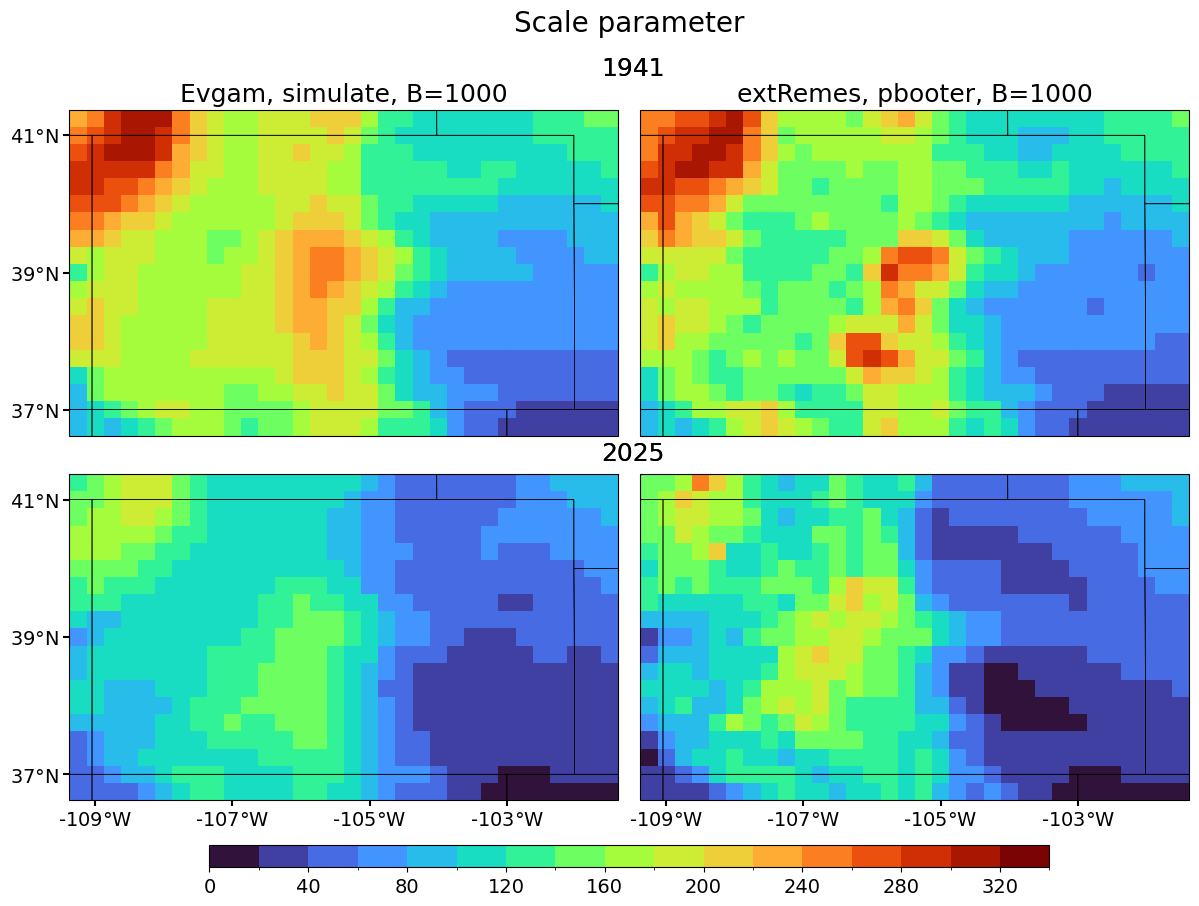

In [39]:
proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=2,ncols=2,figsize=(14,11),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.04)
ax = ax.flatten()
for ix in range(0,2):
  cc = Tscale[ix].sel(time=yearb).plot.pcolormesh(ax=ax[ix],cmap='turbo',levels=np.arange(0,360,20),add_colorbar=False)
  cc = Tscale[ix].sel(time=yeare).plot.pcolormesh(ax=ax[ix+2],cmap='turbo',levels=np.arange(0,360,20),add_colorbar=False)
  fig.text(0.48,0.92,yearb,fontsize=18)
  fig.text(0.48,0.57,yeare,fontsize=18)
  ####
for ix in range(0,len(ax)):  
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
 
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-2:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
    ax[ix].set_title('',fontsize=18)  
  elif ix <=1:
    ax[ix].set_title(f'{Tlabels[ix]}',fontsize=18)    
  else:
    ax[ix].set_title('',fontsize=18) 
for ix in range(0,3,2): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#

ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Scale parameter',fontsize=20)  

Text(0.5, 0.98, 'Shape parameter, year=1941')

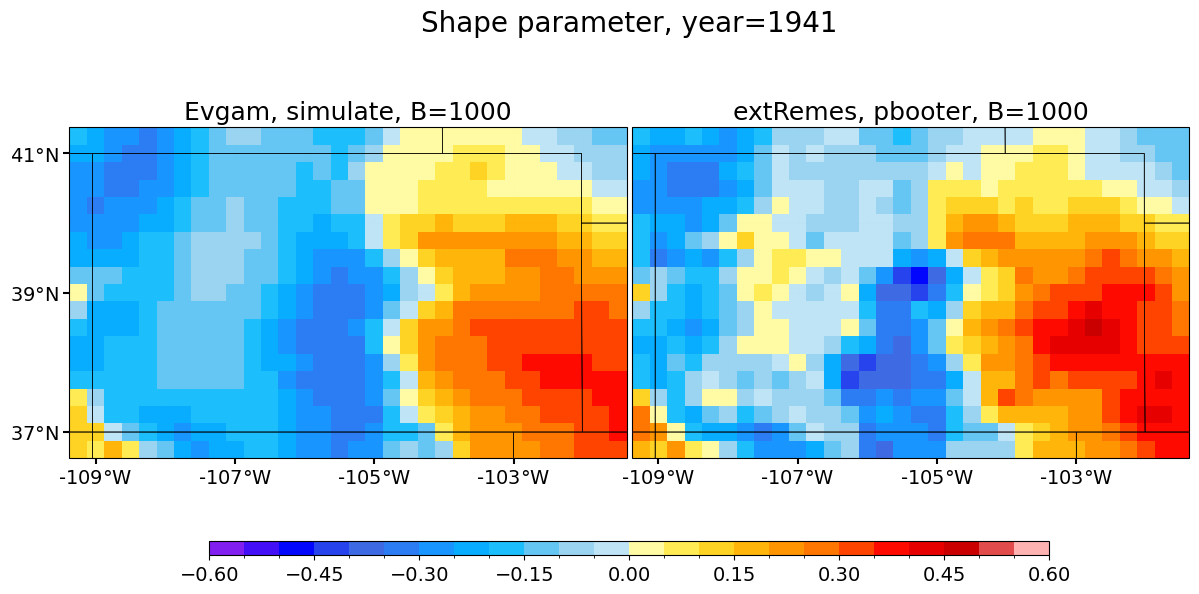

In [40]:
proj=ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.2,left=0.1, right=0.9,top=0.95,hspace=0.01,wspace=0.01)
ax = ax.flatten()
for ix in range(0,2):
  cc = Tshape[ix].sel(time=yearb).plot.pcolormesh(ax=ax[ix],cmap=cmaps.ncl_default,levels=np.arange(-0.6,0.65,0.05),add_colorbar=False)
  ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'{Tlabels[ix]}',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Shape parameter, year={yearb}',fontsize=20)  

In [41]:
import cmaps
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import matplotlib as mpl

# Define colors (names, hex codes, or RGB tuples)
B_colors =["xkcd:periwinkle","darkblue","blue","xkcd:electric blue","xkcd:lightish blue",\
           "xkcd:sky blue","xkcd:powder blue","aliceblue"]
# Create a smooth gradient colormap
Blues_map = mcolors.LinearSegmentedColormap.from_list("my_gradient", B_colors)

# Define colors (names, hex codes, or RGB tuples)
R_colors = ["lightyellow","yellow","gold",  "darkorange","xkcd:blood orange",\
            "xkcd:red","darkred","xkcd:peachy pink"]
# Create a smooth gradient colormap
Reds_map = mcolors.LinearSegmentedColormap.from_list("my_gradient", R_colors)
BR_map = ListedColormap(np.vstack((Blues_map.resampled(128)(np.linspace(0, 1, 128)),Reds_map.resampled(128)(np.linspace(0, 1, 128)))))

Text(0.5, 0.98, 'Difference 2025-1941 fitted Return Level 100 year')

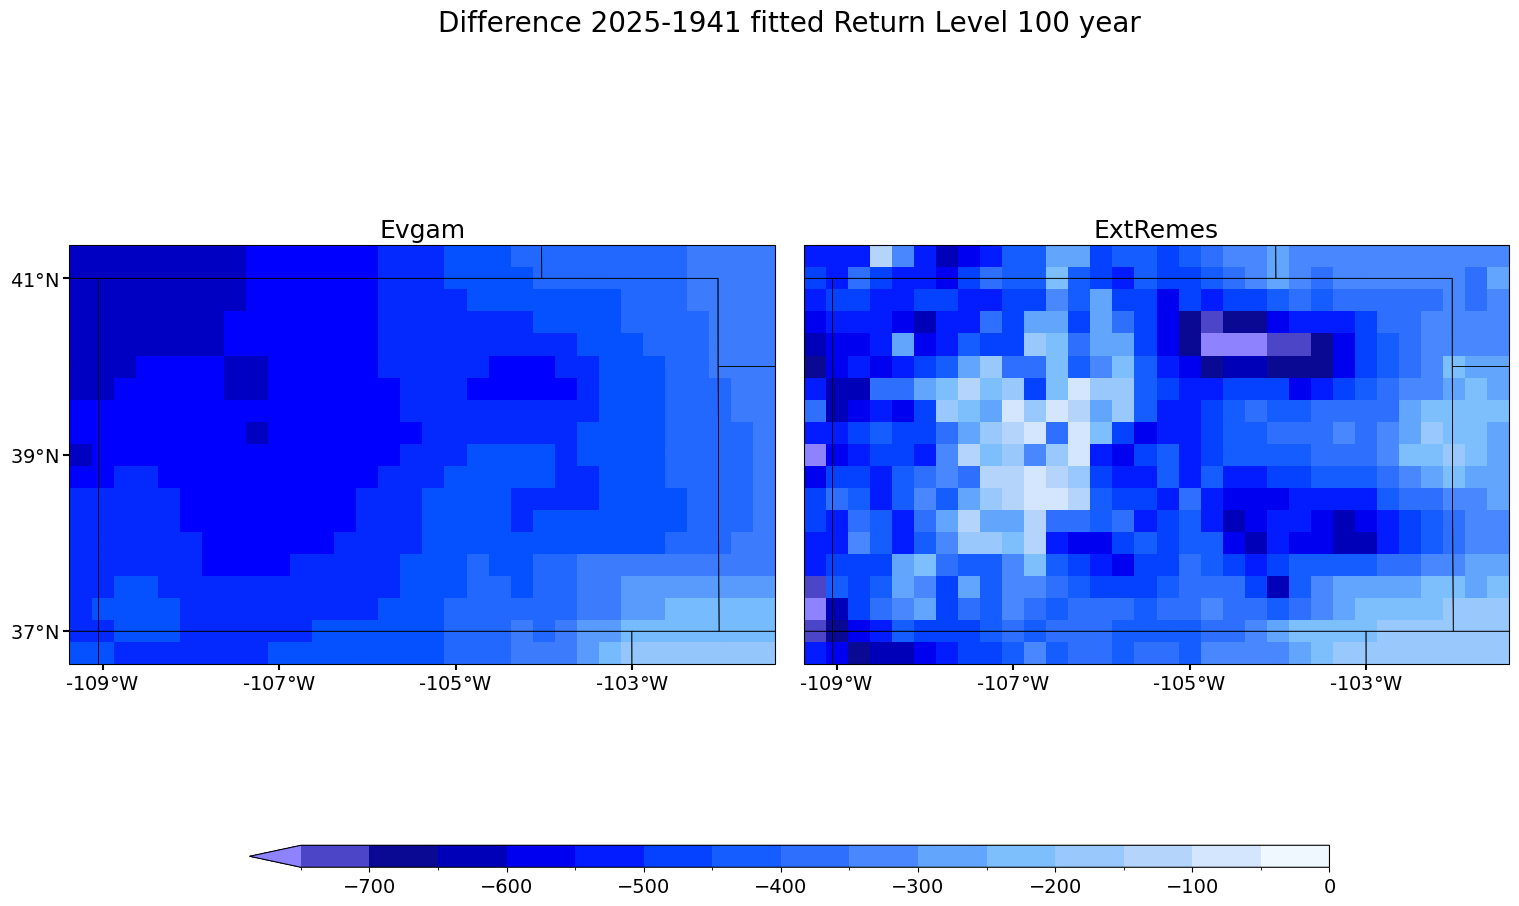

In [42]:
clevs = np.arange(-750,50,50)
cmap = Blues_map

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(18,11),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.04)
ax = ax.flatten()
for ix in range(0,2):
  cc = TRLfitted[ix].plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
ax[0].set_title(f'Evgam',fontsize=18)   
ax[1].set_title(f'ExtRemes',fontsize=18)   
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-3:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
for ix in range(0,len(ax),3): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)

plt.suptitle(f'Difference {yeare}-{yearb} fitted Return Level 100 year',fontsize=20)  

Text(0.5, 0.98, 'Difference 2025-1941 Return Level 100 year')

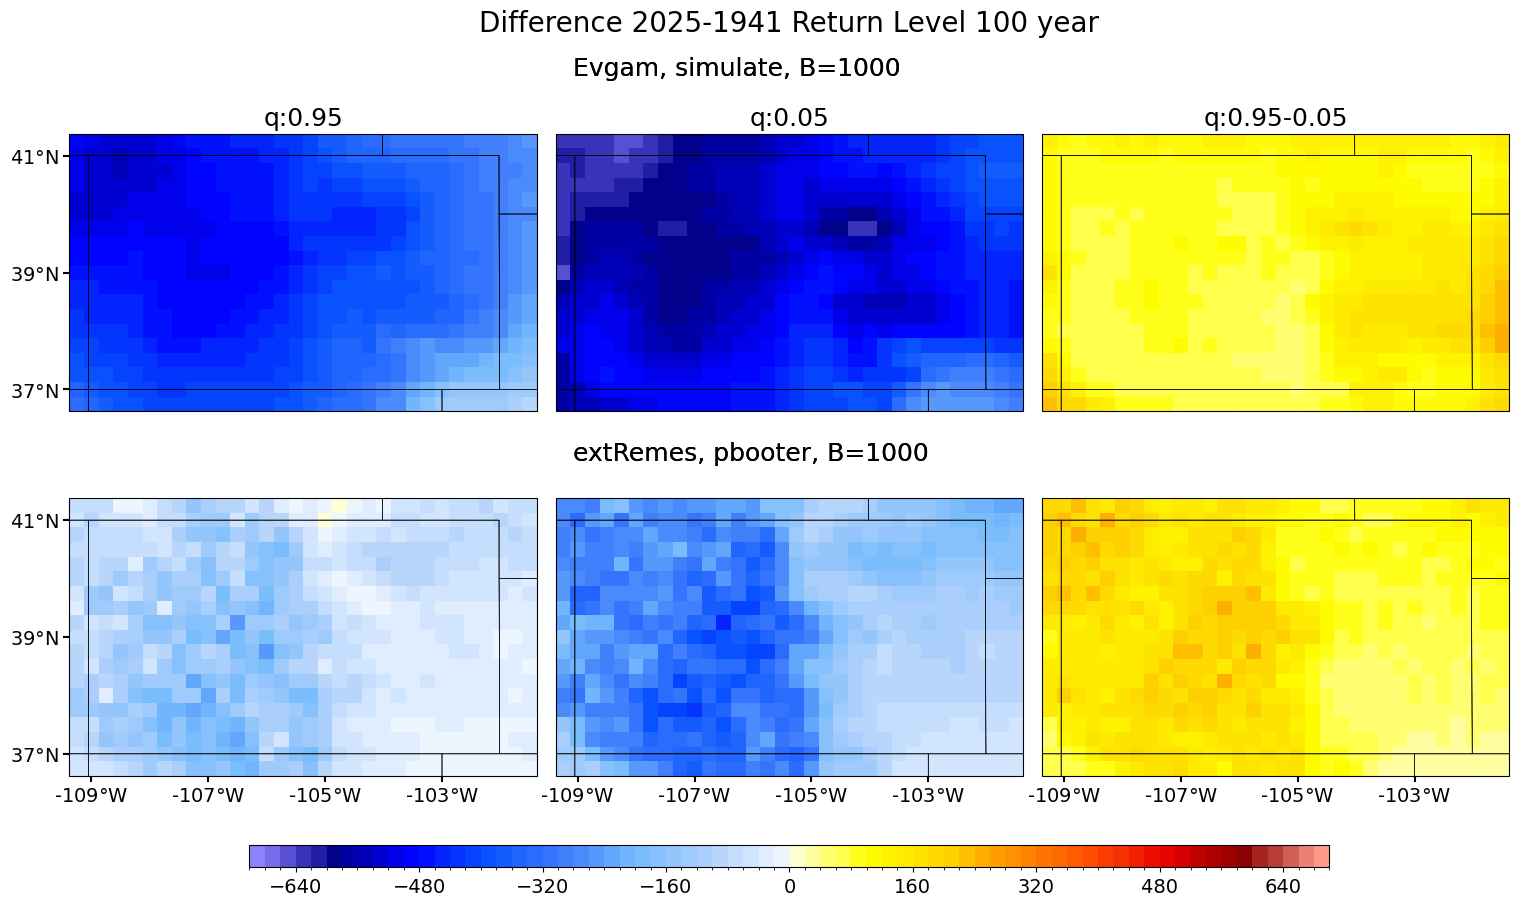

In [43]:
clevs = np.arange(-700,720,20)
cmap = BR_map

fig, ax = plt.subplots(nrows=2,ncols=len(Tquantile),figsize=(18,11),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)-1):
  cc = TRL[0].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
  cc = TRL[1].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+3],levels=clevs,cmap=cmap,add_colorbar=False)
  fig.text(0.38,0.92,f'{Tlabels[0]}',fontsize=18)
  fig.text(0.38,0.57,f'{Tlabels[1]}',fontsize=18)
  ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
  ax[ix+3].set_title(f'',fontsize=18)   
##
ix=2
(TRL[0].sel(quantile=0.95)-TRL[0].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
(TRL[1].sel(quantile=0.95)-TRL[1].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix+3],levels=clevs,cmap=cmap,add_colorbar=False)
ax[ix].set_title(f'q:{Tquantile[2]}',fontsize=18)   
ax[ix+3].set_title(f'',fontsize=18)   
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-3:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
for ix in range(0,4,3): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)

plt.suptitle(f'Difference {yeare}-{yearb} Return Level 100 year',fontsize=20)  

Text(0.5, 0.98, 'Difference 2025-1941 Location parameter')

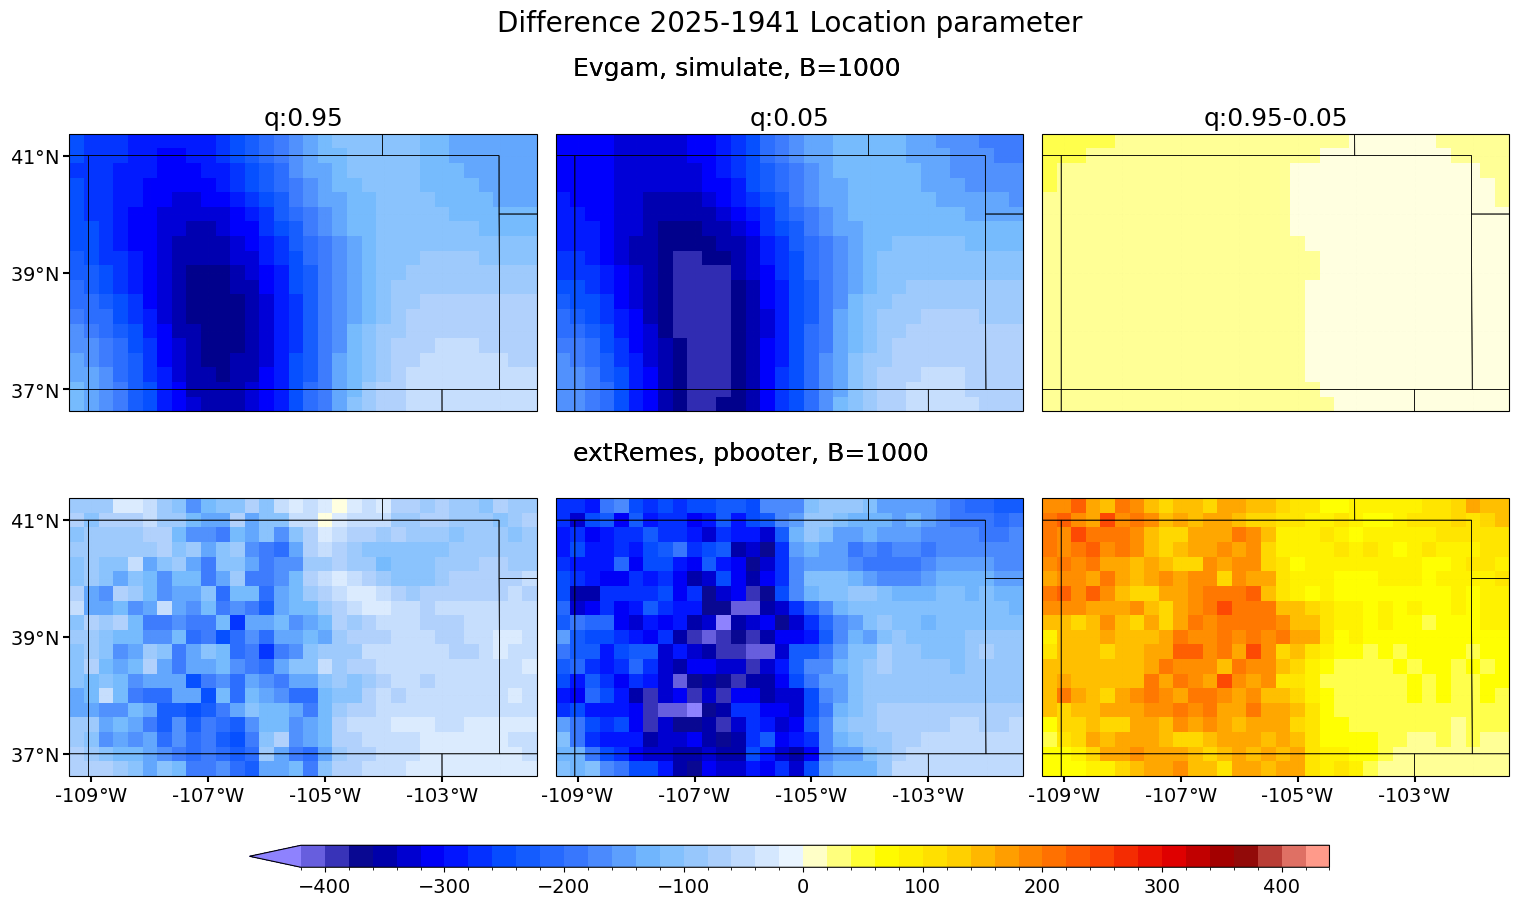

In [44]:
clevs = np.arange(-420,460,20)
cmap = BR_map

fig, ax = plt.subplots(nrows=2,ncols=len(Tquantile),figsize=(18,11),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)-1):
  cc = Tlocdiff[0].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
  cc = Tlocdiff[1].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+3],levels=clevs,cmap=cmap,add_colorbar=False)
  fig.text(0.38,0.92,f'{Tlabels[0]}',fontsize=18)
  fig.text(0.38,0.57,f'{Tlabels[1]}',fontsize=18)
  ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
  ax[ix+3].set_title(f'',fontsize=18)   
##
ix=2
(Tlocdiff[0].sel(quantile=0.95)-Tlocdiff[0].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
(Tlocdiff[1].sel(quantile=0.95)-Tlocdiff[1].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix+3],levels=clevs,cmap=cmap,add_colorbar=False)
ax[ix].set_title(f'q:{Tquantile[2]}',fontsize=18)   
ax[ix+3].set_title(f'',fontsize=18)   
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

  if ix >=len(ax)-3:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)

for ix in range(0,4,3): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Difference {yeare}-{yearb} Location parameter',fontsize=20)  

Text(0.5, 0.98, 'Difference 2025-1941 Scale parameter')

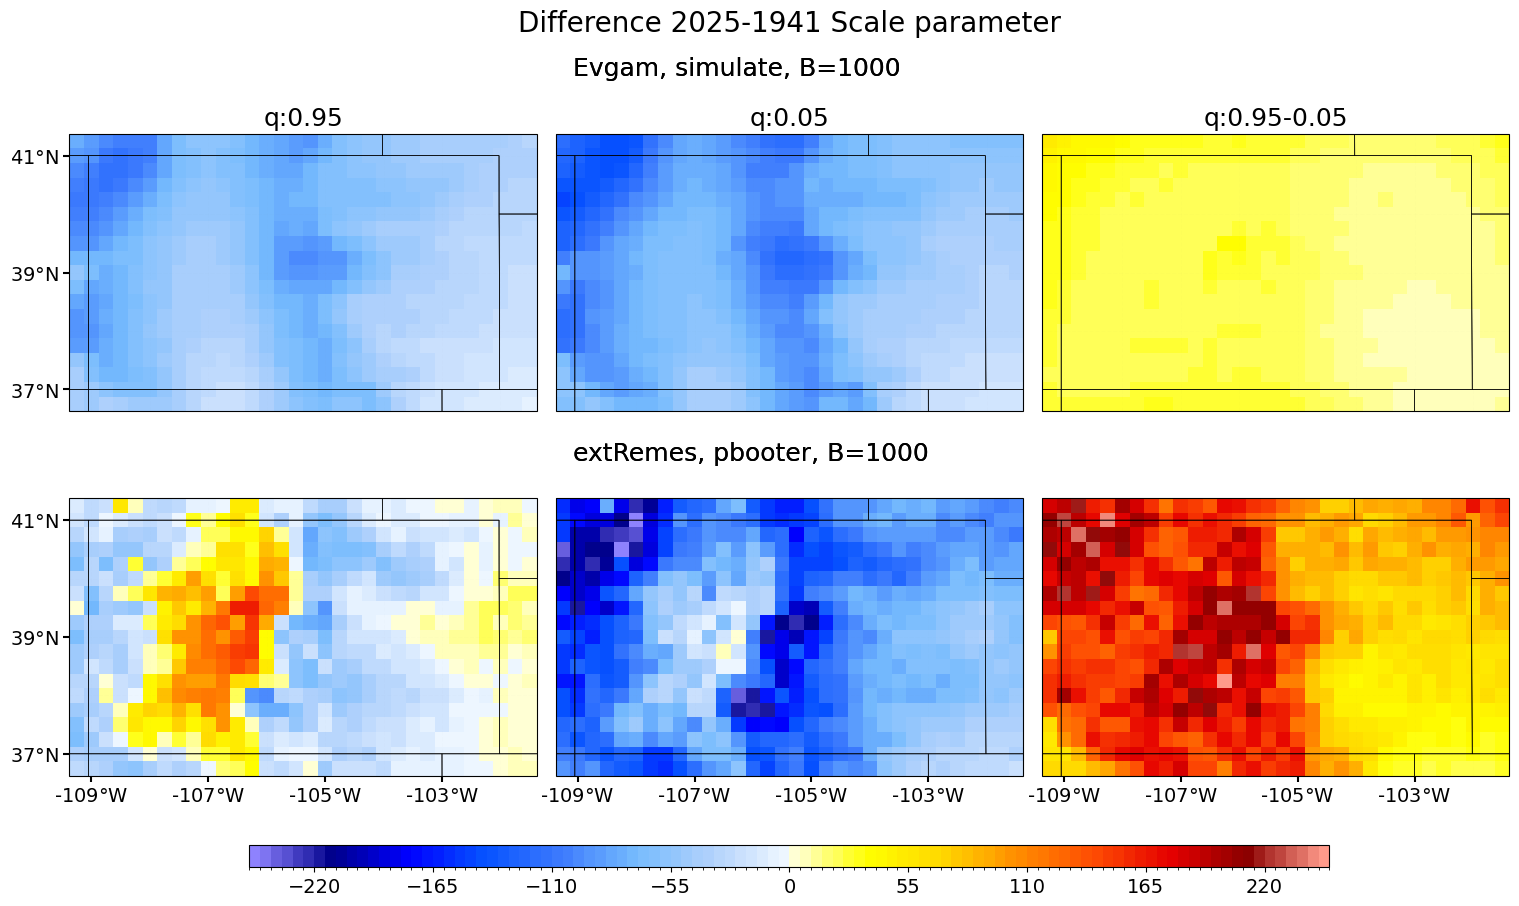

In [45]:
clevs = np.arange(-250,255,5)
cmap = BR_map

fig, ax = plt.subplots(nrows=2,ncols=len(Tquantile),figsize=(18,11),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)-1):
  cc = Tscadiff[0].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
  cc = Tscadiff[1].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+3],levels=clevs,cmap=cmap,add_colorbar=False)
  fig.text(0.38,0.92,f'{Tlabels[0]}',fontsize=18)
  fig.text(0.38,0.57,f'{Tlabels[1]}',fontsize=18)
  ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
  ax[ix+3].set_title(f'',fontsize=18)   
##
ix=2
(Tlocdiff[0].sel(quantile=0.95)-Tlocdiff[0].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
(Tlocdiff[1].sel(quantile=0.95)-Tlocdiff[1].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix+3],levels=clevs,cmap=cmap,add_colorbar=False)
ax[ix].set_title(f'q:{Tquantile[2]}',fontsize=18)   
ax[ix+3].set_title(f'',fontsize=18)   
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

  if ix >=len(ax)-3:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)

for ix in range(0,4,3): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Difference {yeare}-{yearb} Scale parameter',fontsize=20)  

In [46]:
from matplotlib import cm
## Build colorbar
clevsa=np.arange(1.,80,1)
clevsb=np.arange(0,1.1,1)
rr_clevs=np.concatenate((clevsb,clevsa))

##########
##########
rr_cmap = ListedColormap(np.vstack((Blues_map.resampled(128)(96),Reds_map.resampled(len(clevsa))(np.linspace(0, 1, len(clevsa))))))

Text(0.5, 0.98, 'Risk ratios')

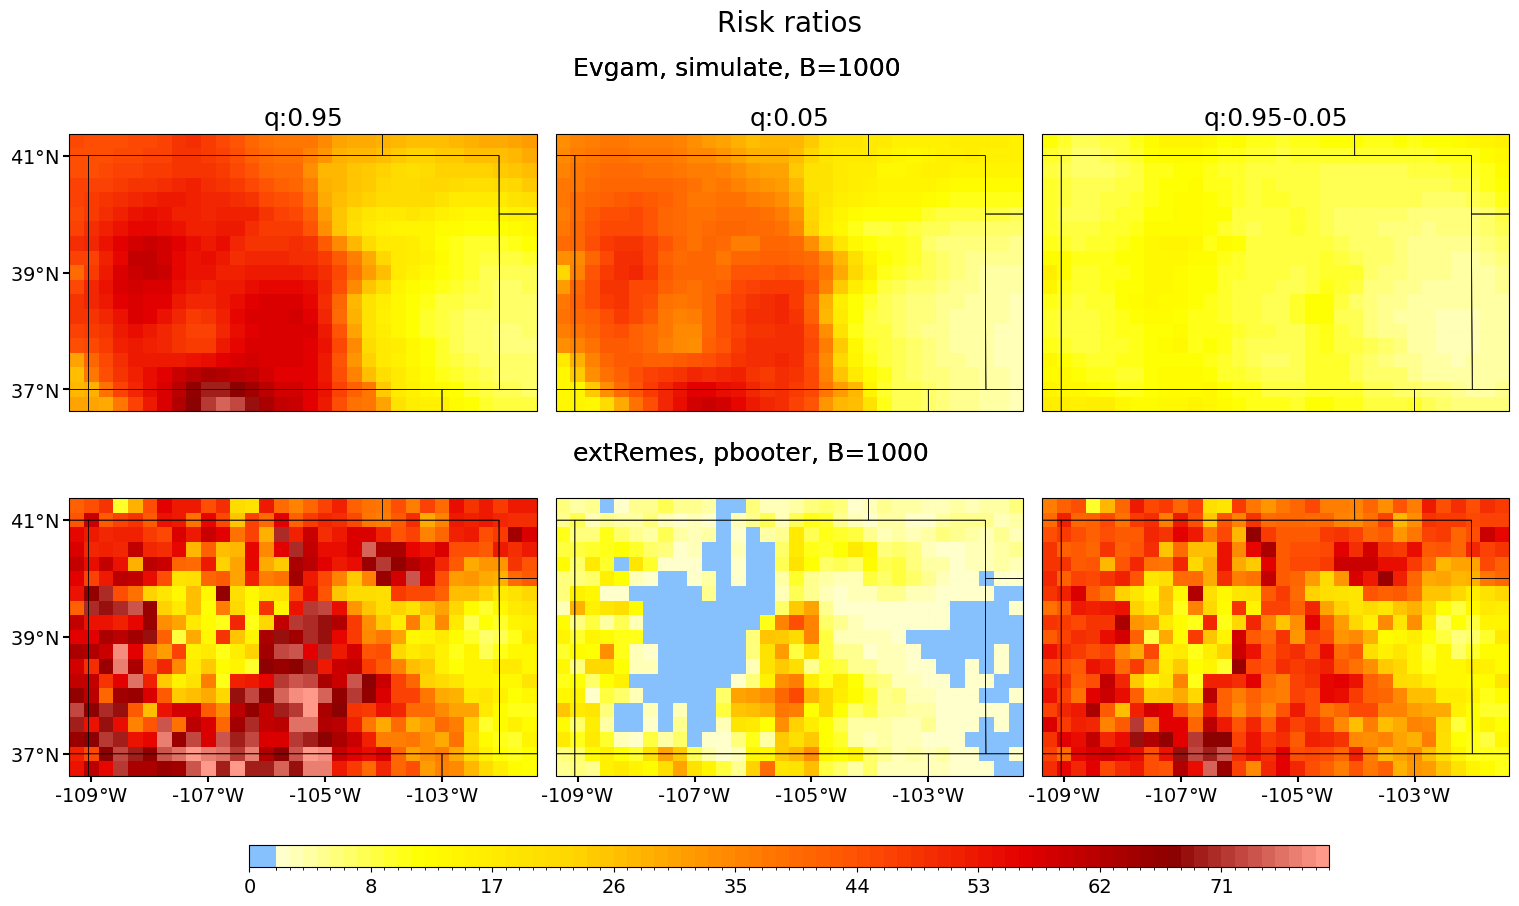

In [47]:
fig, ax = plt.subplots(nrows=2,ncols=len(Tquantile),figsize=(18,11),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)-1):
  cc = TRR[0].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix],cmap=rr_cmap,levels=rr_clevs,add_colorbar=False)
  cc = TRR[1].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+3],cmap=rr_cmap,levels=rr_clevs,add_colorbar=False)
  fig.text(0.38,0.92,f'{Tlabels[0]}',fontsize=18)
  fig.text(0.38,0.57,f'{Tlabels[1]}',fontsize=18)
  ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
  ax[ix+3].set_title(f'',fontsize=18)   
##
ix=2
cc = (TRR[0].sel(quantile=0.95)-TRR[0].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix],cmap=rr_cmap,levels=rr_clevs,add_colorbar=False)
cc = (TRR[1].sel(quantile=0.95)-TRR[1].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix+3],cmap=rr_cmap,levels=rr_clevs,add_colorbar=False)
ax[ix].set_title(f'q:{Tquantile[2]}',fontsize=18)   
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

  if ix >=len(ax)-3:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)

for ix in range(0,4,3): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Risk ratios',fontsize=20)  

# Tests & Scores

In [48]:
from matplotlib import cm
## Build colorbar
clevsa=np.arange(0.06,1.01,0.01)
clevsb=np.arange(0,0.051,0.001)
pvalue_clevs=np.concatenate((clevsb,clevsa))
cmap = cm.get_cmap('Purples',len(clevsa)+20)
cmaplist = [cmap(i) for i in range(20,cmap.N)]
cmap2 = cm.get_cmap('YlGn_r', len(clevsb)+5)
cmaplist2 = [cmap2(i) for i in range(0,cmap2.N-5)]

pvalue_cmap = colors.LinearSegmentedColormap.from_list('Custom cmap',\
                cmaplist2+cmaplist, len(cmaplist2)+len(cmaplist))

##########
##########

Text(0.5, 0.98, 'Tests - p.value')

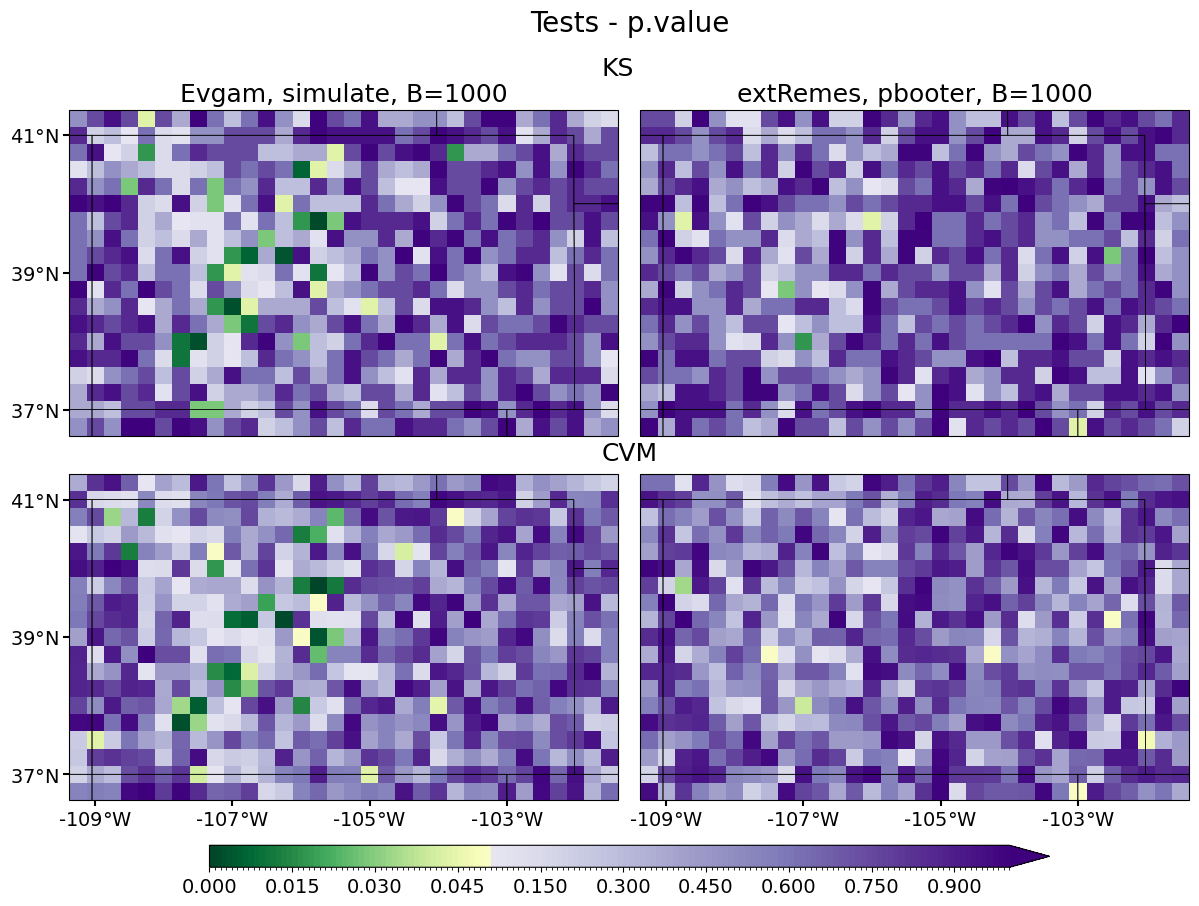

In [49]:
fig, ax = plt.subplots(nrows=2,ncols=2,figsize=(14,11),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.04)
ax = ax.flatten()
for ix in range(0,2):
  cc = TKS_pvalue[ix].plot.pcolormesh(ax=ax[ix],cmap=pvalue_cmap,levels=pvalue_clevs,add_colorbar=False)
  cc = TCVM_pvalue[ix].plot.pcolormesh(ax=ax[ix+2],cmap=pvalue_cmap,levels=pvalue_clevs,add_colorbar=False)
fig.text(0.48,0.92,'KS',fontsize=18)
fig.text(0.48,0.57,'CVM',fontsize=18)
####
for ix in range(0,len(ax)):  
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
 
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-2:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
    ax[ix].set_title('',fontsize=18)  
  elif ix <=1:
    ax[ix].set_title(f'{Tlabels[ix]}',fontsize=18)    
  else:
    ax[ix].set_title('',fontsize=18) 
for ix in range(0,3,2): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#

ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Tests - p.value',fontsize=20)  

Text(0.5, 0.98, 'Tests')

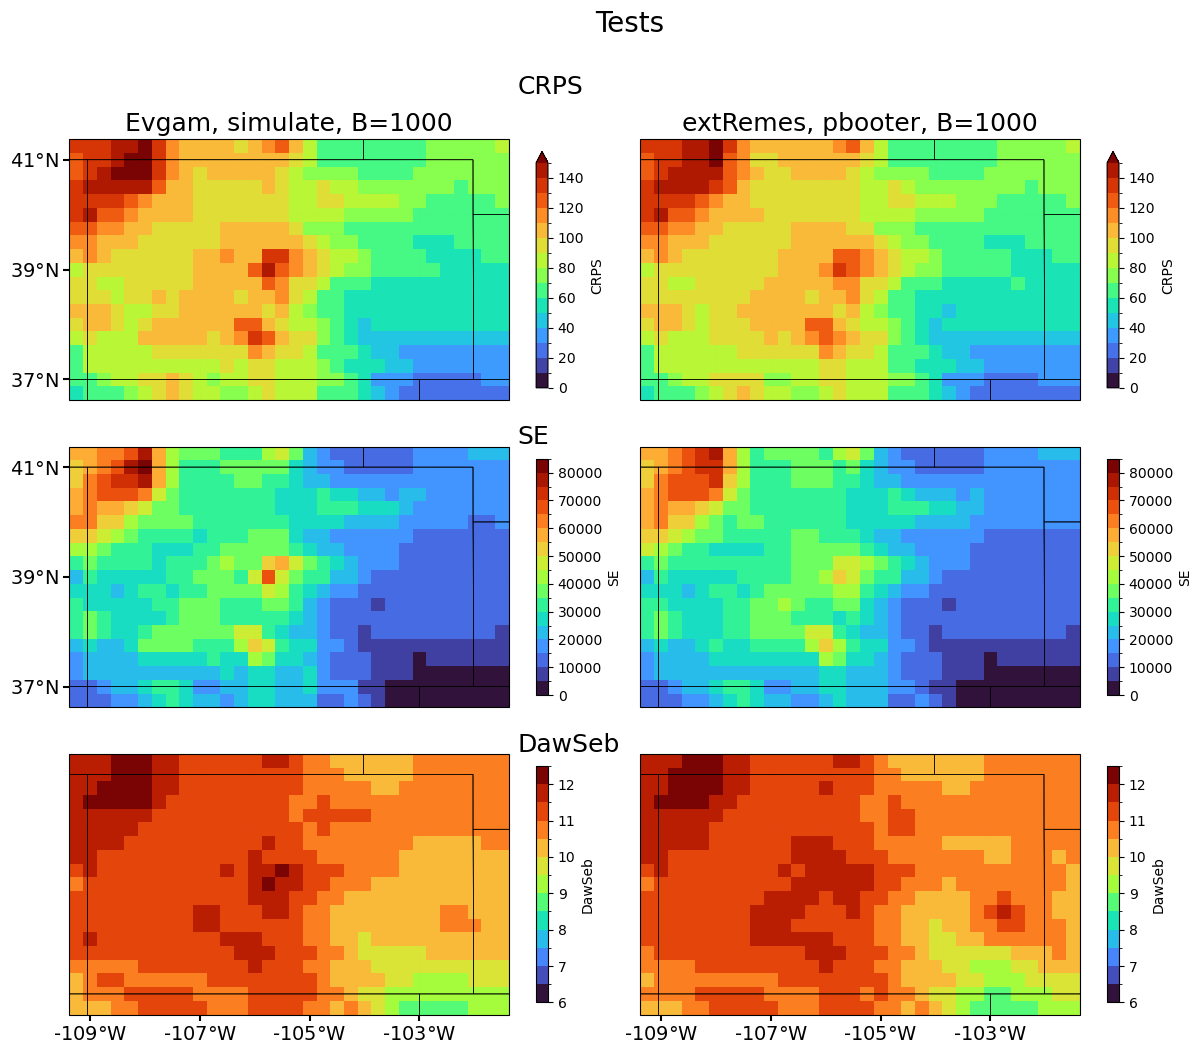

In [50]:
fig, ax = plt.subplots(nrows=3,ncols=2,figsize=(14,14),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.04)
ax = ax.flatten()
for ix in range(0,2):
  TCRPS[ix].mean('time').plot.pcolormesh(ax=ax[ix],cmap='turbo',levels=np.arange(0,160,10),cbar_kwargs={'shrink':0.8})
  TSE[ix].mean('time').plot.pcolormesh(ax=ax[ix+2],cmap='turbo',levels=np.arange(0,90000,5000),cbar_kwargs={'shrink':0.8})
  TDawSeb[ix].mean('time').plot.pcolormesh(ax=ax[ix+4],cmap='turbo',levels=np.arange(6,13,0.5),cbar_kwargs={'shrink':0.8})
fig.text(0.42,0.92,'CRPS',fontsize=18)
fig.text(0.42,0.67,'SE',fontsize=18)
fig.text(0.42,0.45,'DawSeb',fontsize=18)
####
for ix in range(0,len(ax)):  
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
 
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-2:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
    ax[ix].set_title('',fontsize=18)  
  elif ix <=1:
    ax[ix].set_title(f'{Tlabels[ix]}',fontsize=18)    
  else:
    ax[ix].set_title('',fontsize=18) 
for ix in range(0,3,2): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#

plt.suptitle(f'Tests',fontsize=20)  